# Capítulo 7 · Backpropagation: aprender desde el error

En el cuaderno anterior partimos de gradientes conocidos y los utilizamos para corregir parámetros mediante descenso por gradiente. Ahora resolveremos la pregunta que había quedado abierta: **¿cómo obtenemos esos gradientes cuando la pérdida se encuentra al final de una cadena de operaciones?**

Seguiremos una red mínima con dos pesos. Primero realizaremos la propagación hacia adelante, después calcularemos la pérdida y finalmente recorreremos las dependencias en sentido inverso. El objetivo no es construir una red útil, sino hacer visible el mecanismo de backpropagation.

## Objetivos del cuaderno

Al finalizar este recorrido podrás:

- diferenciar *forward pass*, backpropagation y actualización de parámetros;
- seguir los valores intermedios de una red mínima;
- interpretar la regla de la cadena como un encadenamiento de sensibilidades;
- calcular manualmente los gradientes de dos pesos;
- verificar esos gradientes mediante pequeñas perturbaciones numéricas;
- observar cómo una activación ReLU puede permitir o bloquear un gradiente;
- reconocer qué cálculos automatiza un framework de Deep Learning.

## Importación de librerías

Usaremos NumPy para los cálculos, Pandas para ordenar los resultados y Matplotlib para representar las relaciones entre operaciones y gradientes.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.6f}".format

## 1. Una red mínima

Trabajaremos con una entrada $x$, una activación intermedia $a_1$ y una salida $\hat{y}$. Dejaremos de lado los bias y utilizaremos activaciones lineales para que cada operación pueda seguirse sin dificultad:

$$a_1=w_1x$$

$$\hat{y}=w_2a_1$$

La pérdida para una única observación será:

$$L=(y-\hat{y})^2$$

Usaremos $x=2$, $y=2$, $w_1=0.5$ y $w_2=1.5$.

In [35]:
x = 2.0
y_real = 2.0
w1 = 0.5
w2 = 1.5

# Forward pass: los valores avanzan desde la entrada hasta la pérdida.
a1 = w1 * x
y_pred = w2 * a1
perdida = (y_real - y_pred) ** 2

forward = pd.DataFrame({
    "Etapa": ["Entrada", "Activación intermedia", "Predicción", "Pérdida"],
    "Operación": ["x", "a1 = w1 · x", "ŷ = w2 · a1", "L = (y − ŷ)²"],
    "Resultado": [x, a1, y_pred, perdida],
})

display(forward)

,Etapa,Operación,Resultado
0,Entrada,x,2.000000
1,Activación intermedia,a1 = w1 · x,1.000000
2,Predicción,ŷ = w2 · a1,1.500000
3,Pérdida,L = (y − ŷ)²,0.250000


La información avanzó desde `x = 2` hasta una predicción de `1.5`. Al compararla con el valor real `2`, obtuvimos una pérdida de `0.25`.

Este valor mide el error, pero todavía no indica cuánto contribuyó cada peso. `w2` aparece cerca de la salida, mientras que `w1` influye primero sobre `a1` y solo después sobre la predicción.

## 2. Comenzar el recorrido hacia atrás

Backpropagation parte de la pérdida y calcula cómo cambia respecto de resultados cada vez más anteriores. La primera pregunta es:

**¿cómo cambia la pérdida cuando cambia la predicción?**

Para:

$$L=(y-\hat{y})^2$$

la derivada respecto de la predicción es:

$$\frac{\partial L}{\partial \hat{y}}=2(\hat{y}-y)$$

Después preguntamos cómo cambia $\hat{y}$ respecto de $w_2$. Como $\hat{y}=w_2a_1$:

$$\frac{\partial \hat{y}}{\partial w_2}=a_1$$

In [36]:
dL_dy_pred = 2 * (y_pred - y_real)
dy_pred_dw2 = a1
dL_dw2 = dL_dy_pred * dy_pred_dw2

ultimo_peso = pd.DataFrame({
    "Cantidad": ["∂L/∂ŷ", "∂ŷ/∂w2", "∂L/∂w2"],
    "Cálculo": [
        "2 · (ŷ − y)",
        "a1",
        "(∂L/∂ŷ) · (∂ŷ/∂w2)",
    ],
    "Resultado": [dL_dy_pred, dy_pred_dw2, dL_dw2],
})

display(ultimo_peso)

,Cantidad,Cálculo,Resultado
0,∂L/∂ŷ,2 · (ŷ − y),-1.000000
1,∂ŷ/∂w2,a1,1.000000
2,∂L/∂w2,(∂L/∂ŷ) · (∂ŷ/∂w2),-1.000000


La derivada $\partial L/\partial\hat{y}$ vale `−1`. Al multiplicarla por la sensibilidad de la predicción respecto de `w2`, que vale `1`, obtenemos:

$$\frac{\partial L}{\partial w_2}=-1$$

La multiplicación de esas dos relaciones es una aplicación de la **regla de la cadena**. El gradiente negativo indica que, alrededor de esta posición, aumentar ligeramente `w2` reduciría la pérdida.

## 3. La regla de la cadena para un peso más lejano

Para llegar hasta $w_1$ debemos recorrer una dependencia adicional:

$$w_1\rightarrow a_1\rightarrow\hat{y}\rightarrow L$$

La cadena completa es:

$$
\frac{\partial L}{\partial w_1}
=
\frac{\partial L}{\partial\hat{y}}
\frac{\partial\hat{y}}{\partial a_1}
\frac{\partial a_1}{\partial w_1}
$$

Como $\hat{y}=w_2a_1$, tenemos $\partial\hat{y}/\partial a_1=w_2$. Como $a_1=w_1x$, resulta $\partial a_1/\partial w_1=x$.

In [37]:
dy_pred_da1 = w2
da1_dw1 = x

# Este gradiente intermedio se reutiliza para continuar hacia w1.
dL_da1 = dL_dy_pred * dy_pred_da1
dL_dw1 = dL_da1 * da1_dw1

primer_peso = pd.DataFrame({
    "Cantidad": ["∂L/∂ŷ", "∂ŷ/∂a1", "∂L/∂a1", "∂a1/∂w1", "∂L/∂w1"],
    "Resultado": [dL_dy_pred, dy_pred_da1, dL_da1, da1_dw1, dL_dw1],
})

display(primer_peso)

,Cantidad,Resultado
0,∂L/∂ŷ,-1.000000
1,∂ŷ/∂a1,1.500000
2,∂L/∂a1,-1.500000
3,∂a1/∂w1,2.000000
4,∂L/∂w1,-3.000000


El gradiente intermedio $\partial L/\partial a_1$ vale `−1.5`. Backpropagation reutiliza ese resultado para continuar hacia la operación anterior. Finalmente obtenemos:

$$\frac{\partial L}{\partial w_1}=-3$$

Los gradientes de los dos pesos son diferentes: `−3` para `w1` y `−1` para `w2`. Ambos participaron en la misma predicción, pero su influencia sobre la pérdida no fue idéntica.

### El recorrido completo

Durante el recorrido hacia adelante se conservan valores como `x`, `a1` y la predicción. Durante el recorrido hacia atrás esos resultados se reutilizan para calcular gradientes sin reconstruir desde cero toda la dependencia de cada peso.

## 4. Verificar los gradientes mediante perturbaciones

Podemos comprobar los resultados manuales modificando cada peso una cantidad muy pequeña y observando cómo cambia la pérdida. Utilizaremos una aproximación centrada:

$$
\frac{\partial L}{\partial w}
\approx
\frac{L(w+\varepsilon)-L(w-\varepsilon)}{2\varepsilon}
$$

Esta verificación numérica no reemplaza backpropagation en una red real: requeriría repetir cálculos para cada parámetro y sería muy costosa. Aquí funciona como control didáctico.

In [38]:
def calcular_perdida(x, y_real, w1, w2):
    a1 = w1 * x
    y_pred = w2 * a1
    return (y_real - y_pred) ** 2

epsilon = 1e-5

gradiente_numerico_w1 = (
    calcular_perdida(x, y_real, w1 + epsilon, w2)
    - calcular_perdida(x, y_real, w1 - epsilon, w2)
) / (2 * epsilon)

gradiente_numerico_w2 = (
    calcular_perdida(x, y_real, w1, w2 + epsilon)
    - calcular_perdida(x, y_real, w1, w2 - epsilon)
) / (2 * epsilon)

verificacion = pd.DataFrame({
    "Peso": ["w1", "w2"],
    "Gradiente por backpropagation": [dL_dw1, dL_dw2],
    "Gradiente numérico": [gradiente_numerico_w1, gradiente_numerico_w2],
    "Diferencia absoluta": [
        abs(dL_dw1 - gradiente_numerico_w1),
        abs(dL_dw2 - gradiente_numerico_w2),
    ],
})

display(verificacion)

,Peso,Gradiente por backpropagation,Gradiente numérico,Diferencia absoluta
0,w1,-3.000000,-3.000000,0.000000
1,w2,-1.000000,-1.000000,0.000000


Los gradientes numéricos coinciden con `−3` y `−1` hasta una diferencia extremadamente pequeña. Esto respalda el recorrido realizado con la regla de la cadena.

Un framework obtiene gradientes de forma analítica y eficiente mediante diferenciación automática; no necesita perturbar cada peso de esta manera.

### Visualizar la pendiente respecto de cada peso

Mantendremos fijo un peso mientras variamos el otro. De esa forma obtendremos dos cortes del paisaje de pérdida y podremos observar la pendiente local en la posición actual.

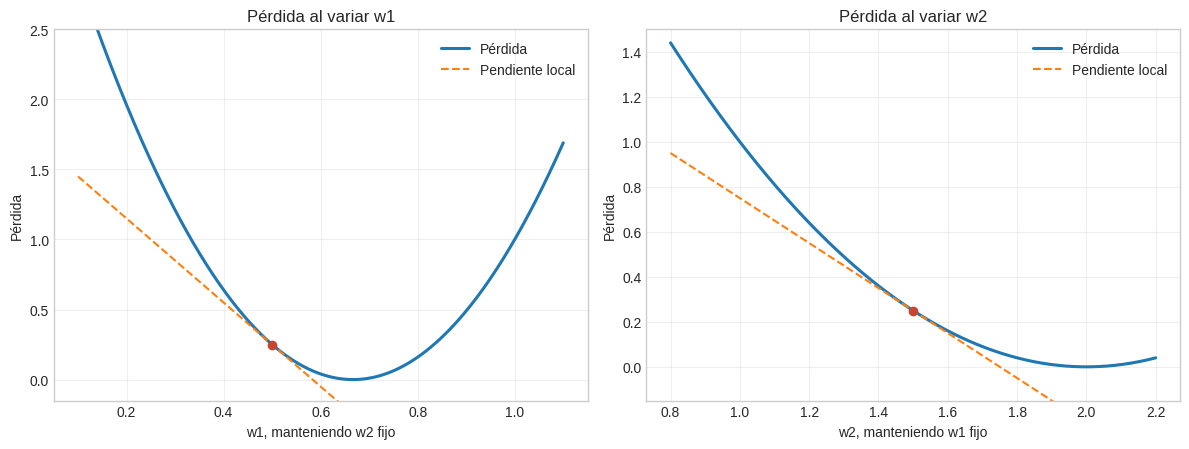

In [39]:
valores_w1 = np.linspace(0.1, 1.1, 300)
valores_w2 = np.linspace(0.8, 2.2, 300)

perdidas_w1 = [calcular_perdida(x, y_real, valor, w2) for valor in valores_w1]
perdidas_w2 = [calcular_perdida(x, y_real, w1, valor) for valor in valores_w2]

tangente_w1 = perdida + dL_dw1 * (valores_w1 - w1)
tangente_w2 = perdida + dL_dw2 * (valores_w2 - w2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].plot(valores_w1, perdidas_w1, linewidth=2.2, label="Pérdida")
axes[0].plot(valores_w1, tangente_w1, "--", label="Pendiente local")
axes[0].scatter(w1, perdida, color="#c84630", zorder=3)
axes[0].set_title("Pérdida al variar w1")
axes[0].set_xlabel("w1, manteniendo w2 fijo")
axes[0].set_ylabel("Pérdida")
axes[0].set_ylim(-0.15, 2.5)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(valores_w2, perdidas_w2, linewidth=2.2, label="Pérdida")
axes[1].plot(valores_w2, tangente_w2, "--", label="Pendiente local")
axes[1].scatter(w2, perdida, color="#c84630", zorder=3)
axes[1].set_title("Pérdida al variar w2")
axes[1].set_xlabel("w2, manteniendo w1 fijo")
axes[1].set_ylabel("Pérdida")
axes[1].set_ylim(-0.15, 1.5)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

En la posición actual, ambas pendientes son negativas, pero la asociada con `w1` es más pronunciada. La línea discontinua muestra la aproximación local que proporciona el gradiente; no describe toda la curva.

## 5. Backpropagation calcula; el descenso actualiza

Ahora que tenemos los gradientes podemos aplicar una actualización. Este paso pertenece al descenso por gradiente estudiado en el capítulo 6, no a backpropagation.

El ejemplo también permite recordar que el gradiente describe una situación local. Compararemos una tasa `0.10` con otra de `0.01`, actualizando ambos pesos simultáneamente.

In [40]:
comparacion_actualizaciones = []

for learning_rate in [0.10, 0.01]:
    w1_nuevo = w1 - learning_rate * dL_dw1
    w2_nuevo = w2 - learning_rate * dL_dw2
    perdida_nueva = calcular_perdida(x, y_real, w1_nuevo, w2_nuevo)

    comparacion_actualizaciones.append({
        "Learning rate": learning_rate,
        "w1 nuevo": w1_nuevo,
        "w2 nuevo": w2_nuevo,
        "Pérdida anterior": perdida,
        "Pérdida nueva": perdida_nueva,
    })

display(pd.DataFrame(comparacion_actualizaciones))

,Learning rate,w1 nuevo,w2 nuevo,Pérdida anterior,Pérdida nueva
0,0.100000,0.800000,1.600000,0.250000,0.313600
1,0.010000,0.530000,1.510000,0.250000,0.159520


Con `0.10`, ambos cambios simultáneos llevan la predicción más allá del valor correcto y la pérdida aumenta a `0.3136`. Con `0.01`, la pérdida disminuye hasta aproximadamente `0.1595`.

Los gradientes no estaban equivocados. Fueron calculados correctamente en la posición original; el primer paso simplemente resultó demasiado grande para este ejemplo. Esta comprobación conecta backpropagation con el *learning rate* sin volver a desarrollar el contenido del capítulo anterior.

## 6. El papel de una función de activación

Hasta ahora usamos activaciones lineales. En una red real, backpropagation también debe atravesar las funciones de activación.

Para ReLU:

$$\operatorname{ReLU}(z)=\max(0,z)$$

su derivada simplificada es 0 cuando $z<0$ y 1 cuando $z>0$. Compararemos dos valores de $w_1$: uno produce una entrada positiva a ReLU y el otro una entrada negativa.

In [41]:
def relu(z):
    return np.maximum(0, z)

def derivada_relu(z):
    return np.where(z > 0, 1.0, 0.0)

casos_relu = []

for nombre, w1_relu in [("Región positiva", 0.5), ("Región negativa", -0.5)]:
    z1 = w1_relu * x
    a1_relu = relu(z1)
    y_pred_relu = w2 * a1_relu
    perdida_relu = (y_real - y_pred_relu) ** 2

    dL_dy = 2 * (y_pred_relu - y_real)
    dL_dw1_relu = dL_dy * w2 * derivada_relu(z1) * x

    casos_relu.append({
        "Caso": nombre,
        "z1": z1,
        "ReLU(z1)": a1_relu,
        "Predicción": y_pred_relu,
        "Pérdida": perdida_relu,
        "Derivada ReLU": derivada_relu(z1),
        "∂L/∂w1": dL_dw1_relu,
    })

display(pd.DataFrame(casos_relu))

,Caso,z1,ReLU(z1),Predicción,Pérdida,Derivada ReLU,∂L/∂w1
0,Región positiva,1.000000,1.000000,1.500000,0.250000,1.0,-3.000000
1,Región negativa,-1.000000,0.000000,0.000000,4.000000,0.0,-0.000000


En la región positiva, la derivada de ReLU vale `1` y el gradiente puede continuar hacia `w1`. En la región negativa vale `0`; al aparecer ese factor en la regla de la cadena, el gradiente respecto de `w1` queda anulado.

Esto no significa que ReLU sea una mala activación. Muestra que la activación forma parte del recorrido hacia atrás y puede modificar la información que llega a capas anteriores.

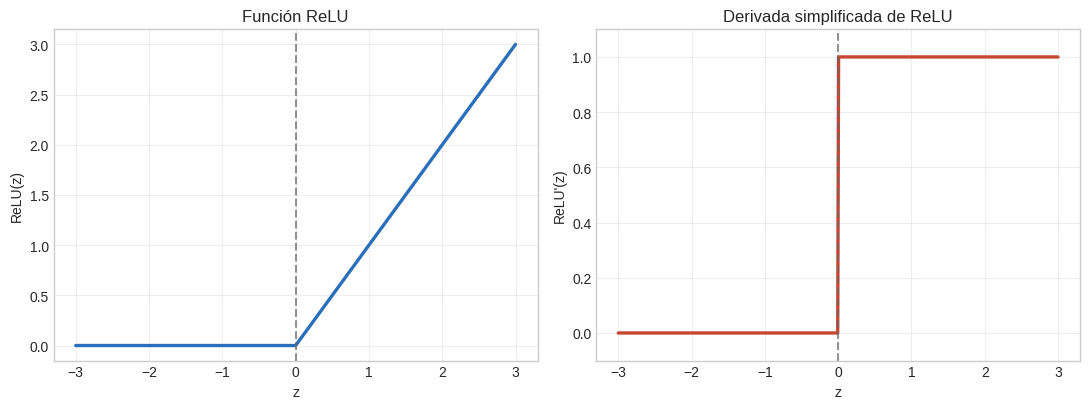

In [42]:
z = np.linspace(-3, 3, 500)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(z, relu(z), color="#2a6fbb", linewidth=2.4)
axes[0].axvline(0, color="#666666", linestyle="--", alpha=0.7)
axes[0].set_title("Función ReLU")
axes[0].set_xlabel("z")
axes[0].set_ylabel("ReLU(z)")
axes[0].grid(alpha=0.3)

axes[1].plot(z, derivada_relu(z), color="#c84630", linewidth=2.4)
axes[1].axvline(0, color="#666666", linestyle="--", alpha=0.7)
axes[1].set_title("Derivada simplificada de ReLU")
axes[1].set_xlabel("z")
axes[1].set_ylabel("ReLU'(z)")
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

El gráfico de la derecha permite ver el factor que backpropagation utiliza al atravesar ReLU. En `z = 0` existen convenciones diferentes; para esta práctica usamos derivada `0`. Esa decisión no modifica la idea central del ejemplo.

## 7. De dos pesos a muchas capas

En una red densa, cada capa realiza operaciones matriciales y aplica una activación. Durante el *forward pass* se conservan resultados intermedios como entradas, sumas ponderadas y activaciones. Durante backpropagation, la regla de la cadena se aplica desde las capas finales hacia las iniciales.

En cada capa se obtienen gradientes respecto de sus pesos y bias. El principio es el mismo que utilizamos con `w1` y `w2`, aunque las cantidades sean matrices y vectores.

| Etapa | Qué circula | Dirección conceptual |
|---|---|---|
| *Forward pass* | Valores y activaciones | Entrada → salida |
| Cálculo de pérdida | Comparación entre $y$ y $\hat{y}$ | En la salida |
| Backpropagation | Sensibilidades y gradientes | Pérdida → primeras capas |
| Optimización | Actualizaciones de parámetros | Se aplica a cada parámetro |

Los ejemplos de entrenamiento no atraviesan físicamente la red al revés. Lo que se propaga hacia atrás es información sobre cómo cambia la pérdida.

## 8. Qué automatiza el framework

TensorFlow registra las operaciones realizadas durante el *forward pass* y construye las dependencias necesarias para aplicar después la regla de la cadena. Este mecanismo se conoce como **diferenciación automática**.

Conceptualmente, el framework realiza lo mismo que hicimos a mano:

1. calcula la predicción;
2. calcula la pérdida;
3. obtiene el gradiente respecto de la salida;
4. recorre las operaciones en sentido inverso;
5. calcula los gradientes de todos los parámetros;
6. entrega esos gradientes al optimizador.

Automatizar el procedimiento no hace desaparecer el mecanismo. Cuando más adelante entrenemos una red sin escribir derivadas explícitas, TensorFlow seguirá realizando cálculos equivalentes a estos.

## 9. Actividad breve

Modificá la entrada, el valor real o los pesos. La celda realiza una única pasada hacia adelante y una única propagación hacia atrás. Observá qué gradiente cambia más y relacioná ese resultado con las operaciones de la red.

In [43]:
# Modificá estos valores y volvé a ejecutar la celda.
x_actividad = 1.5
y_actividad = 2.0
w1_actividad = 0.8
w2_actividad = 1.2

# Forward pass.
a1_actividad = w1_actividad * x_actividad
y_pred_actividad = w2_actividad * a1_actividad
perdida_actividad = (y_actividad - y_pred_actividad) ** 2

# Backward pass.
dL_dy_actividad = 2 * (y_pred_actividad - y_actividad)
dL_dw2_actividad = dL_dy_actividad * a1_actividad
dL_dw1_actividad = dL_dy_actividad * w2_actividad * x_actividad

resultado_actividad = pd.DataFrame({
    "Cantidad": ["a1", "ŷ", "L", "∂L/∂w1", "∂L/∂w2"],
    "Valor": [
        a1_actividad,
        y_pred_actividad,
        perdida_actividad,
        dL_dw1_actividad,
        dL_dw2_actividad,
    ],
})

display(resultado_actividad)

,Cantidad,Valor
0,a1,1.200000
1,ŷ,1.440000
2,L,0.313600
3,∂L/∂w1,-2.016000
4,∂L/∂w2,-1.344000


Con los valores iniciales de la actividad, la predicción es `1.44` y la pérdida es `0.3136`. Ambos gradientes son negativos, por lo que un pequeño aumento de cualquiera de los pesos tendería a reducir la pérdida en esa posición.

La celda se detiene después de calcular los gradientes. No repite actualizaciones ni organiza el entrenamiento en épocas o batches.

## Cierre

En este cuaderno seguimos una pasada completa sobre una red mínima. El *forward pass* produjo valores intermedios, una predicción y una pérdida. Backpropagation comenzó en esa pérdida y utilizó la regla de la cadena para calcular primero el gradiente del peso más cercano a la salida y luego el de un peso anterior.

Comprobamos que distintos parámetros pueden recibir gradientes diferentes, verificamos los cálculos mediante perturbaciones numéricas y observamos cómo la derivada de una activación forma parte del recorrido hacia atrás. También separamos dos funciones que suelen aparecer juntas: backpropagation calcula gradientes; el optimizador los utiliza para actualizar parámetros.

Ya comprendemos qué ocurre durante una actualización. El próximo capítulo organizará muchas actualizaciones dentro de un entrenamiento real mediante **épocas, batches y optimizadores**.

## Para pensar

1. ¿Por qué el gradiente de `w1` necesita más factores de la regla de la cadena que el gradiente de `w2`?
2. ¿Qué se propaga realmente hacia atrás durante backpropagation?
3. ¿Por qué backpropagation y descenso por gradiente no son exactamente el mismo procedimiento?

---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
